In [150]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

In [ ]:
df=pd.read_csv('DailyDelhiClimate.csv',parse_dates=['date'], dayfirst=True)

In [ ]:
df.head()

In [ ]:
print(df['date'].dtype)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df.head()

In [ ]:
df.info()
df.describe()

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['meantemp'], color='blue')

plt.tight_layout()
plt.show()

In [ ]:
df_2013 = df[df['date'].dt.year == 2013]

plt.figure(figsize=(12,6))
plt.plot(df_2013['date'], df_2013['meantemp'], color='blue')
plt.show()

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes = axes.flatten()

for month in range(1, 13):
    month_data = df_2013[df_2013['date'].dt.month == month]

    axes[month-1].plot(month_data['date'],month_data['meantemp'],label='Temperature')
    axes[month-1].plot(month_data['date'],month_data['meantemp'].rolling(7).mean(),color='red',linewidth=2,label='Trend')
    axes[month-1].set_title(f'Month: {month}')
    axes[month-1].tick_params(axis='x', rotation=45)
    axes[month-1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X=df[['humidity','wind_speed','meanpressure']]
y=df['meantemp']

X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,Y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_pred=model.predict(X_test)

fig=plt.figure(figsize=(12,6))

plt.scatter(Y_test,y_pred)

min_val = min(Y_test.min(), y_pred.min())
max_val = max(Y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect fit')

plt.xlabel('Actual Meantemp')
plt.ylabel('Predicted Meantemp')
plt.title('Actual vs Predicted Meantemp')


Dominant period: 365.50 days


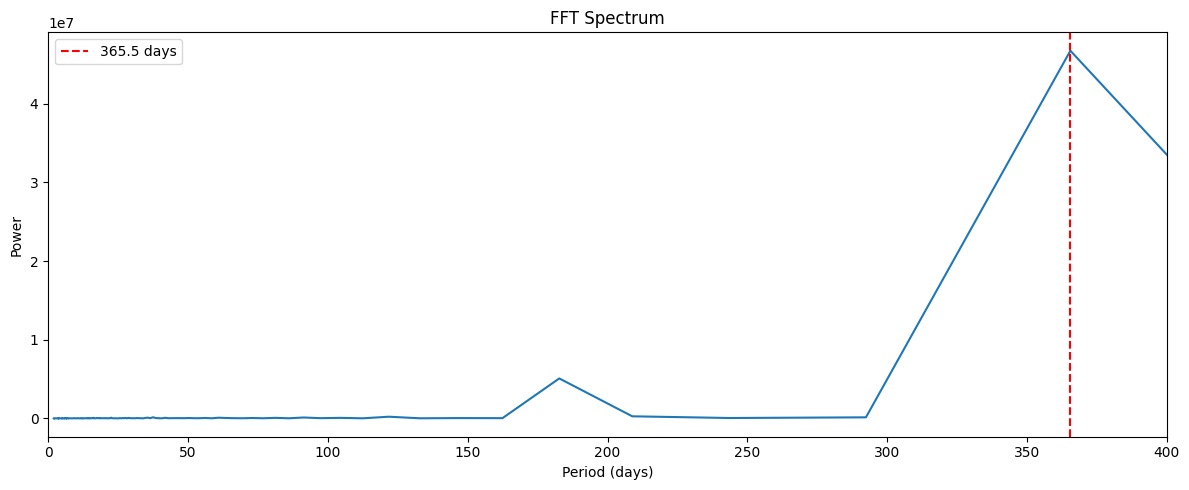

In [191]:
temp = df['meantemp'].dropna().to_numpy()
temp = temp - temp.mean()

fft_values = np.fft.rfft(temp)
freqs = np.fft.rfftfreq(len(temp), d=1)
power = np.abs(fft_values) ** 2

freqs = freqs[1:]
power = power[1:]

idx = np.argmax(power)
dominant_freq = freqs[idx]
dominant_period = 1 / dominant_freq

print(f"Dominant period: {dominant_period:.2f} days")

plt.figure(figsize=(12, 5))
plt.plot(1 / freqs, power)
plt.axvline(dominant_period, color='red', linestyle='--', label=f'{dominant_period:.1f} days')
plt.xlim(0, 400)
plt.xlabel('Period (days)')
plt.ylabel('Power')
plt.title('FFT Spectrum')
plt.legend()
plt.tight_layout()
plt.show()

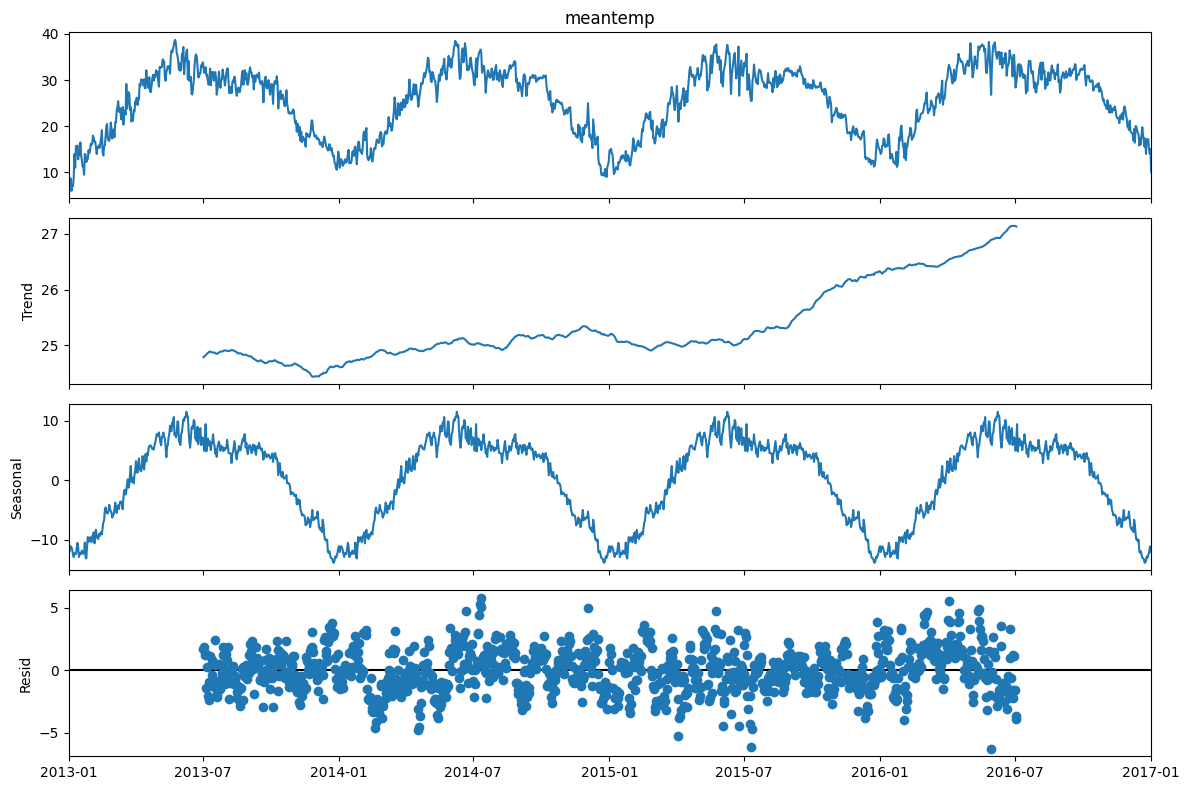

In [ ]:
temp_series = df.set_index('date')['meantemp'].dropna()
add_decomp = seasonal_decompose(temp_series, model='additive', period=365)

fig = add_decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

This time series has a 365.5 day seasonality
A slow long-term Trend
Small residuals in range (-5,5)

This is a non-stationary time series, because of the trend component.